In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Iris.csv')

In [2]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


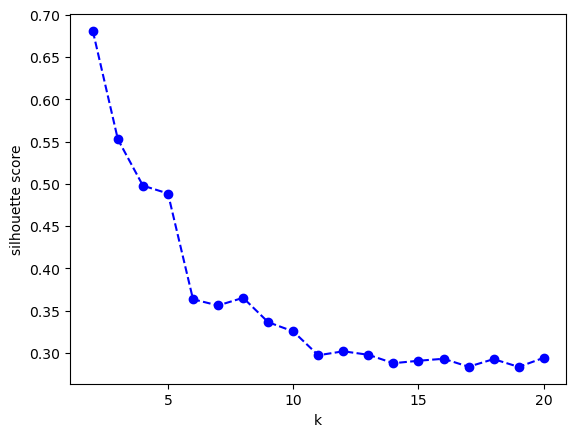

In [3]:

def get_kmeans_score(data, k):
    kmeans = KMeans(n_clusters=k)
    model = kmeans.fit(data)
    return silhouette_score(data, model.labels_, metric='euclidean')

results = []
k_list = list(range(2,21))

for k in k_list:
    results.append(get_kmeans_score(df.iloc[:,1:5], k))

plt.plot(k_list, results, linestyle='--', marker='o', color='b')
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.locator_params(integer=True)


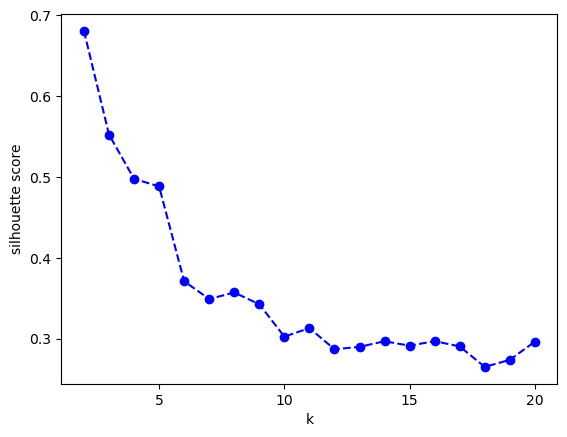

In [4]:


def get_agg_score(data, k):
    agg_clust = AgglomerativeClustering(n_clusters=k)
    model = agg_clust.fit(data)
    return silhouette_score(data, model.labels_, metric='euclidean')

results = []
k_list = list(range(2,21))

for k in k_list:
    results.append(get_kmeans_score(df.iloc[:,1:5], k))

plt.plot(k_list, results, linestyle='--', marker='o', color='b')
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.locator_params(integer=True)


<IPython.core.display.Javascript object>


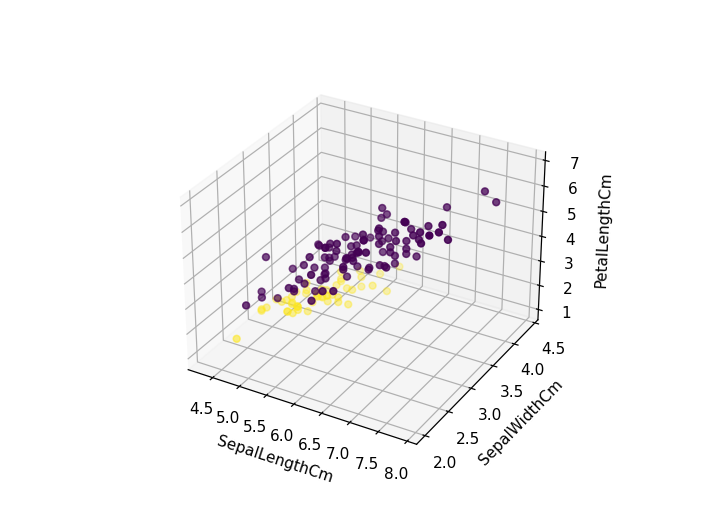

Text(0.5, 0, 'PetalLengthCm')

In [5]:
%matplotlib notebook

agg_clust_2 = AgglomerativeClustering(n_clusters=2)
model_2 = agg_clust_2.fit(df.iloc[:,1:5])
labels_2 = model_2.fit_predict(df.iloc[:,1:5])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df["SepalLengthCm"], df["SepalWidthCm"], df["PetalLengthCm"], c=labels_2)
ax.set_xlabel('SepalLengthCm')
ax.set_ylabel('SepalWidthCm')
ax.set_zlabel('PetalLengthCm')